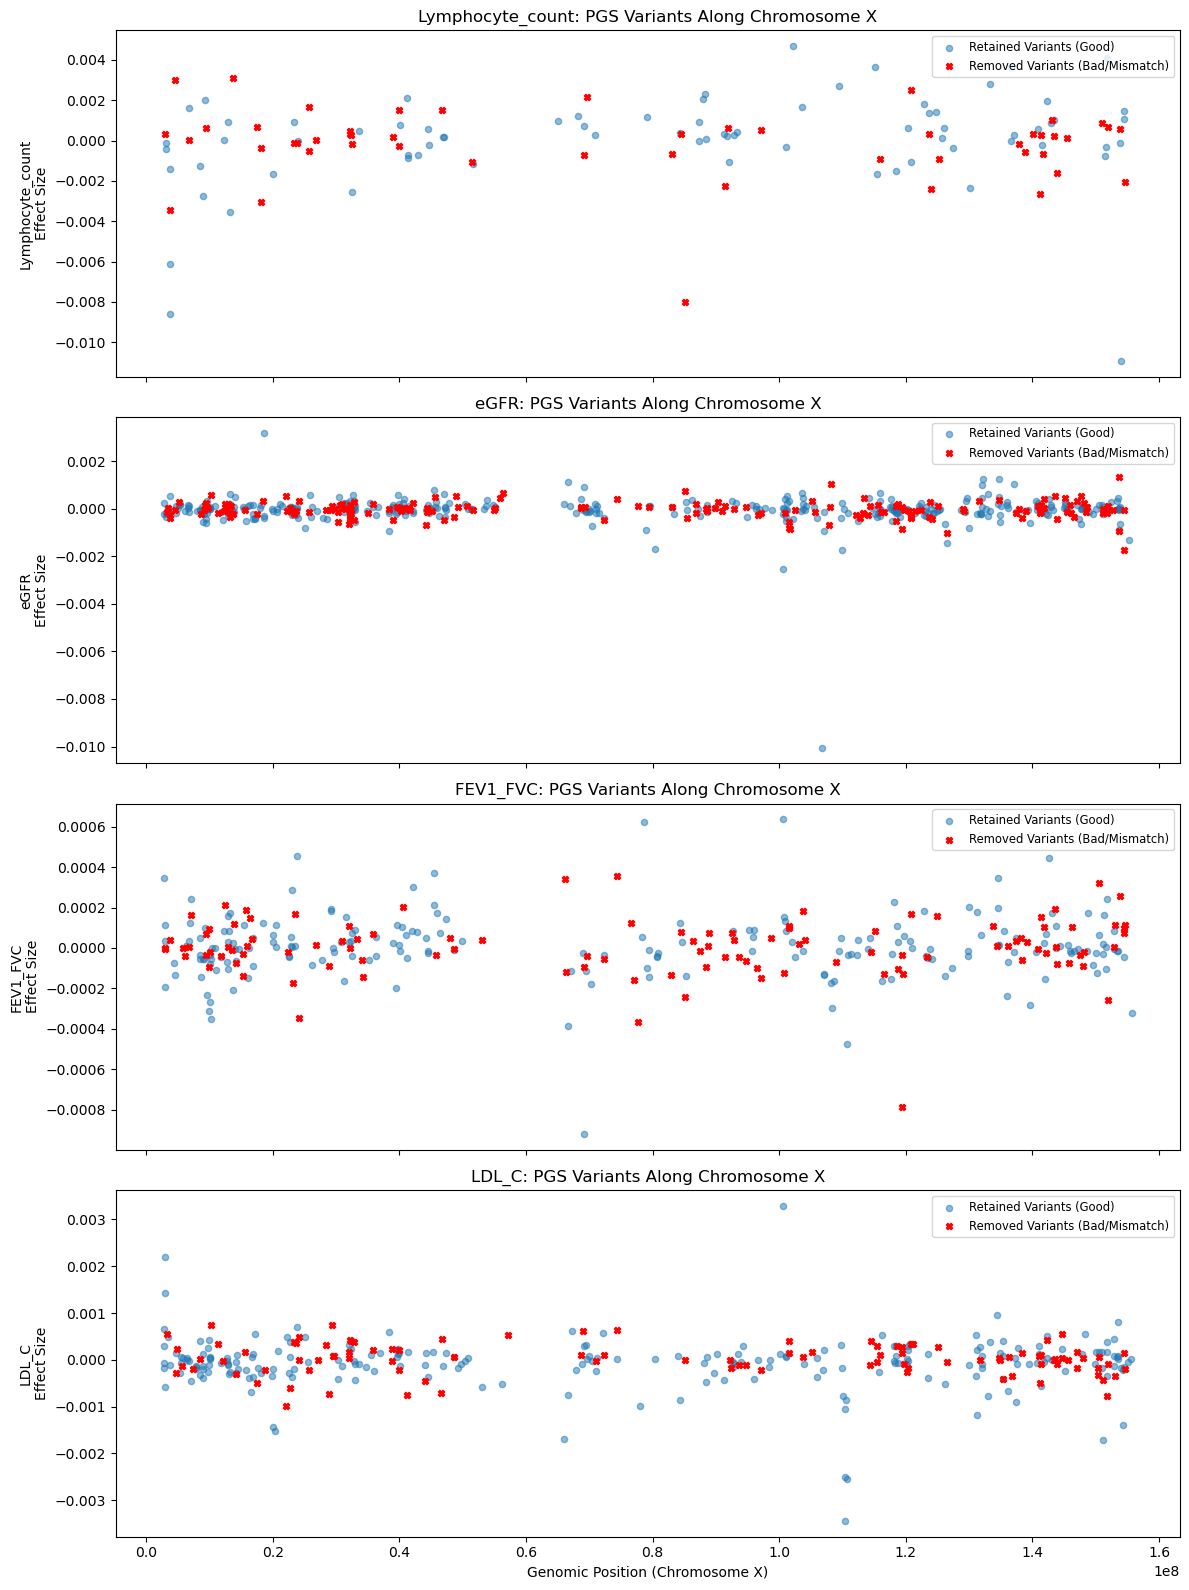

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure fonts are editable in Adobe Illustrator
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

traits = ['Lymphocyte_count', 'eGFR', 'FEV1_FVC', 'LDL_C']
chm_str = 'X'

fig, axes = plt.subplots(len(traits), 1, figsize=(12, 16), sharex=True)

for i, trait in enumerate(traits):
    ax = axes[i]
    
    score_file_path = f"/home/jupyter/workspace/rw-migration-aou-rw-408bb360/scoring_files/{trait}_effect_size_hg38.tsv"
    good_file_path = f"/home/jupyter/workspace/rw-migration-aou-rw-408bb360/scoring_file_filtered/{trait}/chrX_score_for_plink.tsv"

    # Load files
    score_df = pd.read_csv(score_file_path, sep="\t")
    good_df = pd.read_csv(good_file_path, sep="\t")
    good_df['#ID_new'] = 'chr' + good_df['#ID']

    var_col = score_df.columns[0]
    weight_col = 'weight' if 'weight' in score_df.columns else score_df.columns[2]

    # Extract position and chromosome from variant ID
    score_df['pos'] = score_df[var_col].astype(str).str.split(':').str[1].astype(float)
    score_df['chr'] = score_df[var_col].astype(str).str.split(':').str[0].astype(str)
    score_df = score_df[score_df['chr'] == 'chrX']

    # Identify bad variants
    good_variants = set(good_df['#ID_new'])
    score_df['is_bad'] = ~score_df[var_col].isin(good_variants)

    good_subset = score_df[~score_df['is_bad']]
    bad_subset = score_df[score_df['is_bad']]

    # Plot good variants
    ax.scatter(
        good_subset['pos'],
        good_subset[weight_col],
        color='#1f77b4',
        alpha=0.5,
        s=20,
        label='Retained Variants (Good)',
    )

    # Highlight bad/removed variants
    ax.scatter(
        bad_subset['pos'],
        bad_subset[weight_col],
        color='red',
        marker='X',
        s=20,
        label='Removed Variants (Bad/Mismatch)',
    )

    ax.set_ylabel(f'{trait}\nEffect Size')
    ax.set_title(f'{trait}: PGS Variants Along Chromosome {chm_str}')
    ax.legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel(f'Genomic Position (Chromosome {chm_str})')

plt.tight_layout()
#plt.savefig('multi_trait_chrX_variants.pdf', bbox_inches='tight')
plt.show()

Processing Lymphocyte_count...
Processing FEV1_FVC...
Processing eGFR...
Processing LDL_C...


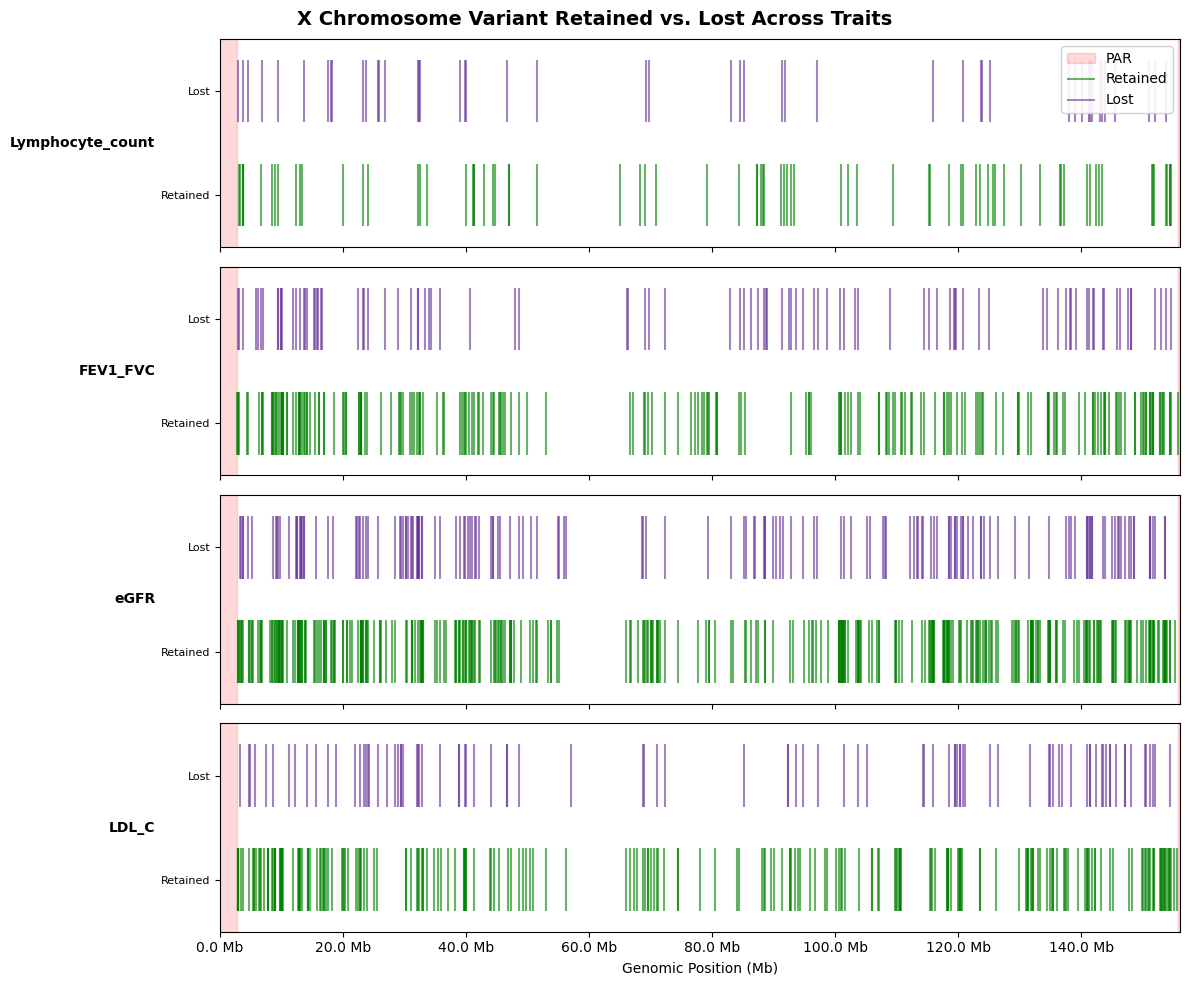

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import subprocess

traits = ['Lymphocyte_count', 'FEV1_FVC', 'eGFR', 'LDL_C']
par1 = (10001, 2781479)
par2 = (155701383, 156030895)

# Set up a figure with 4 rows (one for each trait), sharing the X-axis
fig, axes = plt.subplots(len(traits), 1, figsize=(12, 2.5 * len(traits)), sharex=True)

for i, t in enumerate(traits):
  print(f'Processing {t}...')
  score_file = f'../scoring_files/{t}_effect_size_hg38.tsv'
  score = pd.read_csv(score_file, sep='\t')

  parsed = (
      score['#ID']
      .astype(str)
      .str.replace('^chr', '', regex=True)
      .str.split(':', expand=True)
  )
  score['CHR'] = parsed[0].astype(str)
  score['POS'] = parsed[1].astype(int)

  score_chr = score[score['CHR'] == 'X'].copy()
  if len(score_chr) == 0:
    continue

  pvar_file = f'/home/jupyter/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/acaf_threshold/pgen/acaf_threshold.chrX.pvar'
  cmd = f"grep -v '^##' {pvar_file}"
  pvar = pd.read_csv(
      subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE).stdout,
      sep='\t',
  )
  pvar = pvar[['#CHROM', 'POS', 'ID', 'REF', 'ALT']].copy()
  pvar['CHR'] = pvar['#CHROM'].astype(str).str.replace('^chr', '', regex=True)
  pvar['POS'] = pvar['POS'].astype(int)

  merged = score_chr.merge(pvar, on=['CHR', 'POS'], how='inner')
  lost = score_chr[~score_chr['#ID'].isin(merged['#ID'])]
  retained = score_chr[score_chr['#ID'].isin(merged['#ID'])]

  ax = axes[i]

  # Highlight PAR regions
  ax.axvspan(
      par1[0],
      par1[1],
      color='red',
      alpha=0.15,
      label='PAR' if i == 0 else '',
  )
  ax.axvspan(par2[0], par2[1], color='red', alpha=0.15)

  # Plot Retained (offset 1) and Lost (offset 2) variants as parallel tracks
  ax.eventplot(
      retained['POS'],
      orientation='horizontal',
      colors='green',
      lineoffsets=1,
      linelengths=0.6,
      alpha=0.6,
      label='Retained' if i == 0 else '',
  )
  ax.eventplot(
      lost['POS'],
      orientation='horizontal',
      colors='rebeccapurple',
      lineoffsets=2,
      linelengths=0.6,
      alpha=0.6,
      label='Lost' if i == 0 else '',
  )

  # Label each row with the trait name on the left/y-axis
  ax.set_ylabel(t, fontsize=10, fontweight='bold', rotation=0, ha='right', va='center')
  
  # Set custom ticks to display track labels instead of numbers
  ax.set_yticks([1, 2])
  ax.set_yticklabels(['Retained', 'Lost'], fontsize=8)
  ax.set_ylim(0.5, 2.5)

# Formatting the bottom X-axis
axes[-1].set_xlim(0, 156040895)
axes[-1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f'{x * 1e-6:.1f} Mb')
)
axes[-1].set_xlabel('Genomic Position (Mb)', fontsize=10)

fig.suptitle(
    'X Chromosome Variant Retained vs. Lost Across Traits',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)
axes[0].legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
#plt.savefig('X_retained_vs_lost_all_traits.pdf', bbox_inches='tight')
plt.show()